In [1]:
# SciKit-Learn

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
iris = sns.load_dataset('iris')
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print(type(iris))

<class 'pandas.core.frame.DataFrame'>


In [5]:
print(type(iris.values))

<class 'numpy.ndarray'>


In [6]:
print(iris.shape)

(150, 5)


In [7]:
print(iris.columns)
print(iris.index)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
RangeIndex(start=0, stop=150, step=1)


In [8]:
plt.style.use('classic')

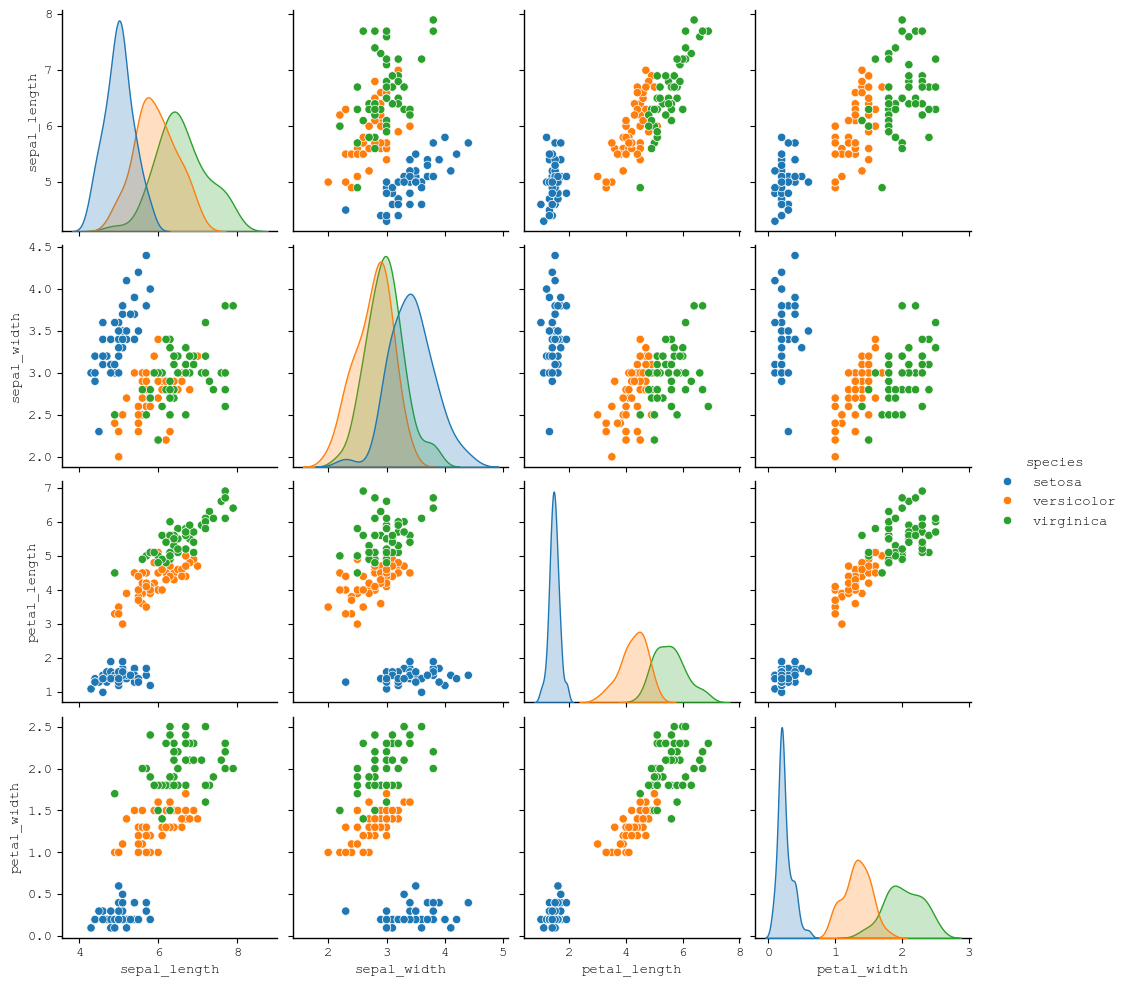

In [9]:
sns.pairplot(iris, hue='species')
plt.show()

In [10]:
# Строки - образцы - отдельный объект (sample)
# Столбцы - признаки (feature)
# Матрица признаков (число образцов на число признаков) - признаки - независимая переменная
# Целевой массив (target or label) [1 на число образцов] - зависимая переменная (зависит от признаков)

Матрица признаков (feature matrix) — это таблица (2D-массив), где строки соответствуют отдельным объектам (образцам), а столбцы — признакам (характеристикам), описывающим эти объекты. Обычно обозначается X. Например, в задаче с цветками ириса: длина чашелистика, ширина чашелистика, длина лепестка, ширина лепестка.

Целевой массив (target array) — это вектор (1D-массив), содержащий метки (целевые значения) для каждого объекта. Он показывает, какой ответ или класс соответствует каждому образцу. Обозначается y. Для ирисов — это вид цветка (setosa, versicolor, virginica).

Связь: задача обучения с учителем — найти закономерность X → y, чтобы по новым признакам предсказывать целевую переменную.

In [11]:
# Матрица признаков
X_iris = iris.drop('species', axis=1)
print(X_iris.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [12]:
# Целевой массив
y_iris = iris['species']
print(y_iris.head())

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [13]:
# 1. Выбирается класс модели
# 2. Выбираются гиперпараметры модели
# 3. На основе данных создаётся матрица признаков и целевой вектор
# 4. Обучение модели fit()
# 5. Обученная модель применяется к новым даным 
#   5.1. Обучение с учителем - predict()
#   5.2. Обучения без учителя - predict() или transform()

In [14]:
# С учителем. Регрессия. Линейная регрессия.

In [15]:
# 1. Выбирается класс модели
from sklearn.linear_model import LinearRegression

In [16]:
# 2. Выбираются гиперпараметры модели
model = LinearRegression(fit_intercept=True) 
# fit_intercept = False, Если из природы задачи или предметной области известно, что при 
# нулевых значениях всех признаков целевая переменная также должна быть равна нулю.

In [17]:
# 3. На основе данных создаётся матрица признаков и целевой вектор
x = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

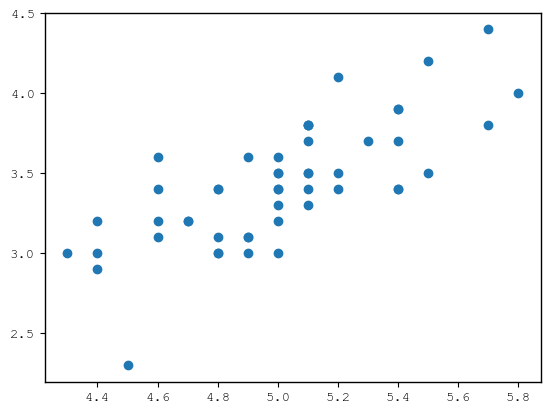

In [18]:
# 4. Обучение модели fit()
reg = model.fit(x[:, np.newaxis], y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = reg.predict(x_fit[:, np.newaxis])

plt.scatter(x, y)
plt.show()

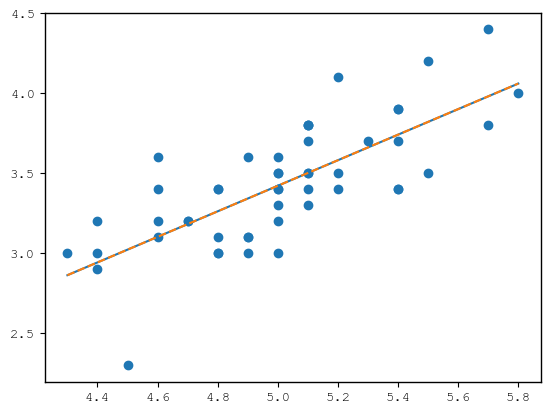

In [19]:
# 5. Обученная модель применяется к новым даным 
#   5.1. Обучение с учителем - predict()
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(x_fit, y_fit)
plt.plot(x_fit, x_fit * reg.coef_ + reg.intercept_, '--') # the same: kx + b

plt.show()
# Конечно, работает не только для линейного случая

In [20]:
# Полиномиальная регрессия

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [22]:
model = make_pipeline(PolynomialFeatures(7), LinearRegression())
reg = model.fit(x[:, np.newaxis], y)

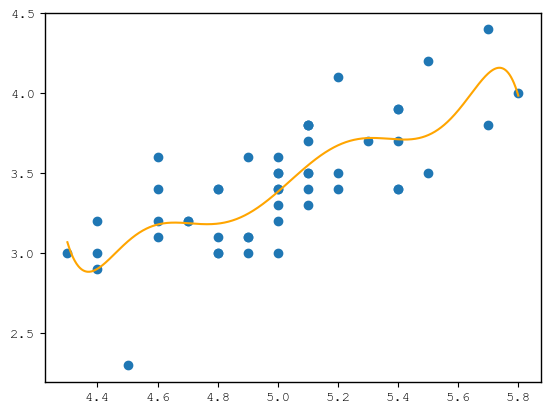

In [23]:
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(x_fit, y_fit, color='orange')

plt.show()

In [24]:
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [25]:
# Классификация. Логистическая регрессия

In [26]:
x_0 = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y_0 = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

x_1 = iris[iris['species'] == 'versicolor'].iloc[:, 0].to_numpy()
y_1 = iris[iris['species'] == 'versicolor'].iloc[:, 1].to_numpy()

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [28]:
x = iris[iris['species'] != 'virginica'].iloc[:, 0].to_numpy()
print(x.shape)
y = iris[iris['species'] != 'virginica'].iloc[:, 4]
print(y.shape)

(100,)
(100,)


In [29]:
# Эта модель обучается предсказывать вид ириса (setosa или versicolor)
# по одному признаку — длине чашелистика (sepal length).
log_reg = model.fit(x[:, None], y)

In [30]:
xfit = np.linspace(x.min(), x.max(), 1000)
yfit = log_reg.predict_proba(xfit[:, None]) # с какой вероятностью первый или второй

In [31]:
print(yfit)

[[0.97313538 0.02686462]
 [0.97291008 0.02708992]
 [0.97268294 0.02731706]
 ...
 [0.00691071 0.99308929]
 [0.00685205 0.99314795]
 [0.00679388 0.99320612]]


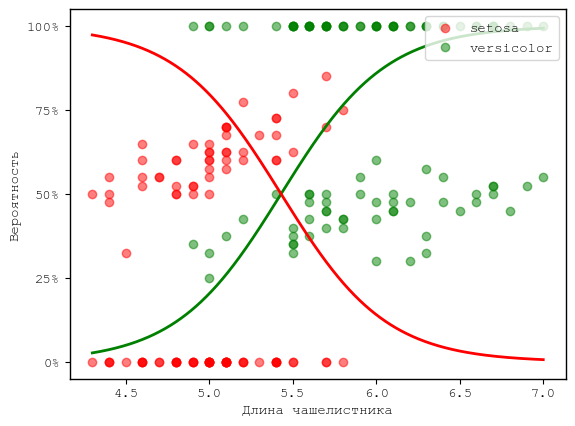

In [32]:
plt.scatter(x_0, y_0, color='red', alpha=0.5)
plt.scatter(x_1, y_1, color='green', alpha=0.5)

plt.scatter(x_0, np.full(50, 1), color='red', alpha=0.5, label='setosa')
plt.scatter(x_1, np.full(50, 5), color='green', alpha=0.5, label='versicolor')

plt.plot(xfit, 1 + 4 * yfit[:, 1], 'green', linewidth=2)
plt.plot(xfit, 1 + 4 * yfit[:, 0], 'red', linewidth=2)

plt.yticks([1, 2, 3, 4, 5], ['0%', '25%', '50%', '75%', '100%'])

plt.xlabel('Длина чашелистника')
plt.ylabel('Вероятность')

plt.legend(loc='upper right')

plt.show()

In [33]:
# Деревья решений

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
x = iris[iris['species'] != 'virginica'].iloc[:, 0:2].to_numpy()
y1 = np.full(50, 1)
y2 = np.full(50, 2)
y = np.ravel([y1, y2])

tree = DecisionTreeClassifier(max_depth=10)
tree.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [36]:
print(np.c_[[1, 2, 3, 4, 5], [10, 20, 30, 40, 50]], end='\n\n')
print(np.ravel([[1, 2, 3, 4, 5], [10, 20, 30, 40, 50]]))

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]
 [ 5 50]]

[ 1  2  3  4  5 10 20 30 40 50]


In [37]:
xx, yy = np.meshgrid(
    np.linspace(x[:, 0].min(), x[:, 0].max(), 100),
    np.linspace(x[:, 1].min(), x[:, 1].max(), 100)   
)

In [38]:
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

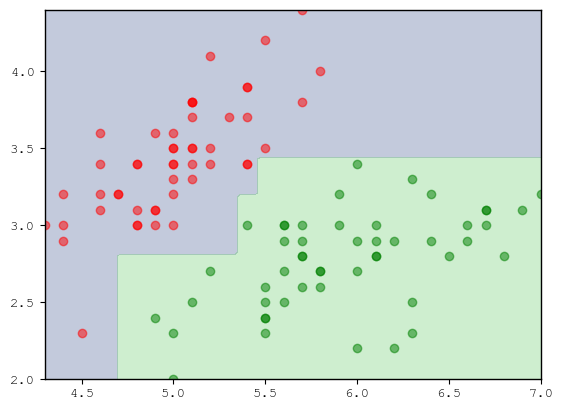

In [39]:
ax = plt.gca()

ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 1.5, 3])

ax.scatter(x_0, y_0, color='red', alpha=0.5)
ax.scatter(x_1, y_1, color='green', alpha=0.5)

plt.show()

In [40]:
# Метод опорных векторов. Классификация
# Support Vector Machine (SVM)

In [41]:
from sklearn.svm import SVC

In [42]:
x = iris[iris['species'] != 'virginica'].iloc[:, 0:2].to_numpy()
y = iris[iris['species'] != 'virginica'].iloc[:, 4]

In [43]:
y1 = np.full(50, 1)
y2 = np.full(50, 2)

In [44]:
y = np.ravel([y1, y2])
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [45]:
model = SVC(kernel='linear', C=1e10) # kernel - ядро
model.fit(x, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [46]:
xx, yy = np.meshgrid(
    np.linspace(x[:, 0].min(), x[:, 0].max(), 100),
    np.linspace(x[:, 1].min(), x[:, 1].max(), 100)   
)

In [47]:
x_0 = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y_0 = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

x_1 = iris[iris['species'] == 'versicolor'].iloc[:, 0].to_numpy()
y_1 = iris[iris['species'] == 'versicolor'].iloc[:, 1].to_numpy()

In [48]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

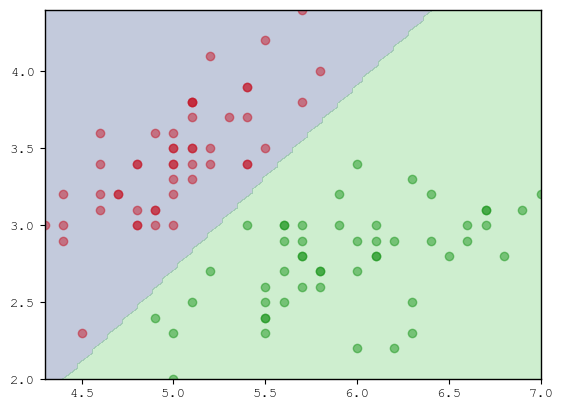

In [49]:
plt.scatter(x_0, y_0, color='red', alpha=0.5)
plt.scatter(x_1, y_1, color='green', alpha=0.5)

ax = plt.gca()
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 1.5, 3])

plt.show()

In [50]:
# Наивная байессовская классификация

In [51]:
from sklearn.naive_bayes import GaussianNB

In [52]:
model = GaussianNB()
model.fit(x, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [53]:
xx, yy = np.meshgrid(
    np.linspace(x[:, 0].min(), x[:, 0].max(), 100),
    np.linspace(x[:, 1].min(), x[:, 1].max(), 100)   
)

In [58]:
x_m = model.theta_[0]    # средние признаков для класса 0 (setosa)
x_var = model.var_[0]    # дисперсии для класса 0
y_m = model.theta_[1]    # средние для класса 1 (versicolor)
y_var = model.var_[1]    # дисперсии для класса 1

In [55]:
z1 = 1 / (2 * np.pi * np.sqrt(x_var[0] * x_var[1])) * np.exp(
    -((xx - x_m[0])**2 / (2 * x_var[0]) 
    + (yy - x_m[1])**2 / (2 * x_var[1]))
)

z2 = 1 / (2 * np.pi * np.sqrt(y_var[0] * y_var[1])) * np.exp(
    -((xx - y_m[0])**2 / (2 * y_var[0]) 
    + (yy - y_m[1])**2 / (2 * y_var[1]))
)

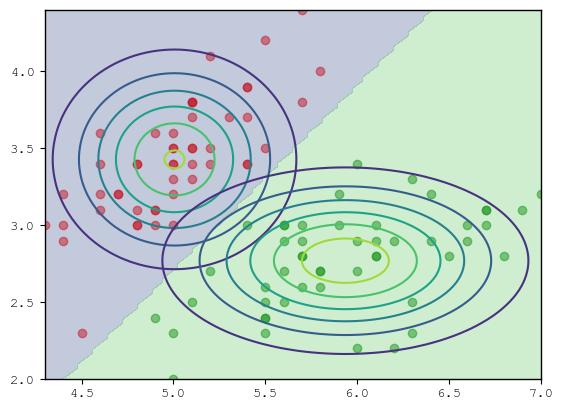

In [56]:
plt.scatter(x_0, y_0, color='red', alpha=0.5)
plt.scatter(x_1, y_1, color='green', alpha=0.5)

plt.contour(xx, yy, z1)
plt.contour(xx, yy, z2)
plt.contourf(xx, yy, Z, alpha=0.3, levels=[0, 1.5, 3])

plt.show()

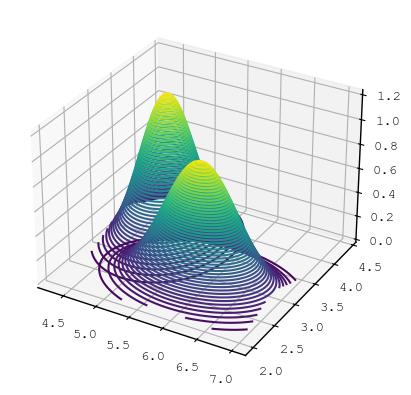

In [57]:
ax = plt.axes(projection='3d')
ax.contour3D(xx, yy, z1, 50)
ax.contour3D(xx, yy, z2, 50)

plt.show()

In [60]:
# k - ближайших соседей

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
model = KNeighborsClassifier()
model.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [63]:
xx, yy = np.meshgrid(
    np.linspace(x[:, 0].min(), x[:, 0].max(), 100),
    np.linspace(x[:, 1].min(), x[:, 1].max(), 100)   
)

In [68]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

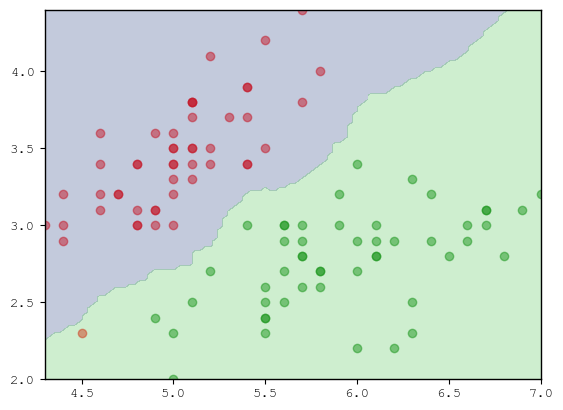

In [69]:
plt.scatter(x_0, y_0, color='red', alpha=0.5)
plt.scatter(x_1, y_1, color='green', alpha=0.5)


plt.contourf(xx, yy, Z, alpha=0.3, levels=[0, 1.5, 3])
plt.show()